# Part 1

> Congratulations—you just won your school’s tabletop football championship! You flicked your lucky paper football to victory countless times, and would now like to frame it for posterity.
>
> The football is an equilateral triangle with a side length of 1 inch. What is the side length of the _smallest_ square frame that will contain the football?


# Solution

We can quickly get a sense of the problem by using some analytical geometry. Let the center of our triangle be at $(0, 0)$ in the plane. Let the vertices of our football then be at

$$
\begin{aligned}
p_1 & = r(\cos t_1, \sin t_1)\\
p_2 & = r(\cos (t_1 + \phi), \sin (t_1 + \phi))\\
p_3 & = r(\cos (t_1 + 2\phi), \sin (t_1 + 2\phi))\\
\end{aligned}
$$

where $\phi = 2 \pi / 3$.
After applying the law-of-cosines to our triangle, we can deduce that $r = 1/ \sqrt 3$.

Now by considering all angles $t_1 \in [0, \phi]$, we will have considered all orientations of the football.

Next, for a given $t_1$ we need to find the smallest square containing it. Since the triangle is convex, it is easy to see that we cannot have the bounding square touch a non-vertex point of the triangle without touching both corresponding vertices of the triangle.
It follows that we only need to concern ourselves with the intersection of the vertices of the triangle with the bounding square.

If we instead consider the smallest axis-parallel bounding rectangle, suppose it has width and length $\Delta x$ and $\Delta y$, the larger of the two will determine the smallest bounding square (otherwise the triangle would poke outside of the square). Therefore, for a given angle $t_1$, we need to find $$\text{Bounding Square Side}(t_1) = \max\{\Delta x(t_1),\Delta y(t_1)\}$$

Where

$$
\begin{aligned}
\Delta x(t_1) & \coloneqq r \bigg(\max\big\{ \cos t_1, \cos (t_1 + \phi),\cos (t_1 + 2\phi) \big\} - \min\big\{ \cos t_1, \cos (t_1 + \phi),\cos (t_1 + 2\phi) \big \} \bigg)\\
\Delta y(t_1)& \coloneqq r \bigg(\max\big\{ \sin t_1, \sin (t_1 + \phi),\sin (t_1 + 2\phi) \big\} - \min\big\{ \sin t_1, \sin (t_1 + \phi),\sin (t_1 + 2\phi) \big \} \bigg)\\
\end{aligned}
$$

Note that we can surmise that the side is maximized when $|\Delta x(t_1) - \Delta y(t_1)|$ is maximized since we will have a lot of wasted space required to make the square. On the other hand, when $\Delta x(t_1) = \Delta y(t_1)$, the square should have zero wasted space and all vertices are touching. Indeed, on $[0, \pi/6]$ we have $\Delta y(t_1) = \cos t_1$ (decreasing) and $\Delta x(t_1) = \cos(\pi/6 - t_1)$ (increasing), so their max is smallest exactly where they cross.

If we put this into Mathematica and run the snippet below:

```Mathematica
r = 1/Sqrt[3];
phi = 2 Pi/3;

dx[t_] :=
 r (Max[Cos[t], Cos[t + phi], Cos[t + 2 phi]] -
    Min[Cos[t], Cos[t + phi], Cos[t + 2 phi]])
dy[t_] :=
 r (Max[Sin[t], Sin[t + phi], Sin[t + 2 phi]] -
    Min[Sin[t], Sin[t + phi], Sin[t + 2 phi]])

(*fetch every  t in[0, phi] where dx==dy.*)
equalAngles = Reduce[PiecewiseExpand[dx[t] - dy[t], 0 <= t <= phi] == 0 && 0 <= t <= phi, t, Reals];
roots = Sort[FullSimplify[t /. {ToRules[equalAngles]}]];
t1Star = First[roots]
sStar = Simplify[dx[t1Star]]
```

We find $\boxed{t_1^* = \pi/12}$ and $\boxed{s^* = \frac{\sqrt{3}+3}{2 \sqrt{6}} \approx 0.966}$

---


# Part 2

> To add a little excitement to the framing process, your new plan is to spin the triangular football by a random angle, and then frame it with a square that is not rotated. That is, the square consists of two perfectly horizontal sides and two perfectly vertical sides.
>
> On average, what can you expect the side length of the smallest resulting square frame to be?


Let $s(t)$ be the minimal bounding square side length for the angle $t$. To find the average of $s$, we simply integrate

$$
\mathbb{E}[s] = \int_0^{2\pi} s(t)\cdot \frac{1}{2\pi} dt
$$

since the random variable of the angle of our arbitrarily chosen first vertex is $U(0, 2\pi)$. By the symmetry from Part 1, averaging over $[0, \phi]$ gives the same result, which is what the code below does.

Leveraging the power of Mathematica (you can tell I am a fan), we have the following code snippet which when run yields

$$
\boxed{\mathbb{E}[s] = \frac{3 \sqrt{2} \left(\sqrt{3}-1\right)}{\pi } \approx 0.989}
$$

```Mathematica
sqSide[t_] := Max[dx[t], dy[t]]

Integrate[sqSide[t]/phi, {t, 0, phi}]
```


# Follow up: Plotting

There are some interesting plots we can create to verify our answers and intuition thus far. First, in Mathematica, we can plot the
side length of the bounding square as a function of $t$.

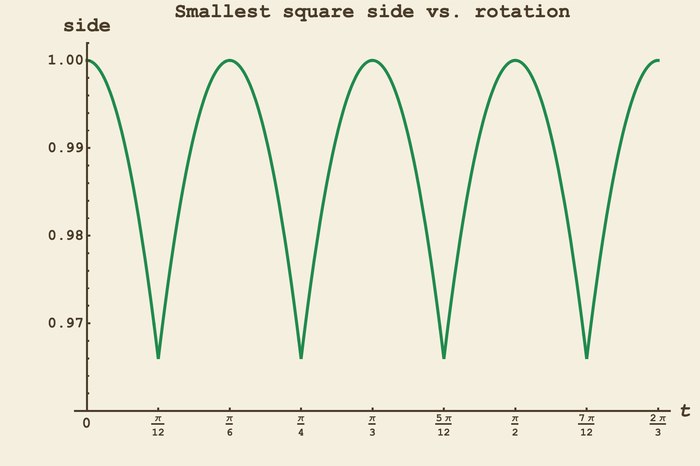

We see that the first minima and maxima align with our earlier stated intuition.

For fun, I had Claude generate a visualization of the triangle and its associated bounding square for each $t$.

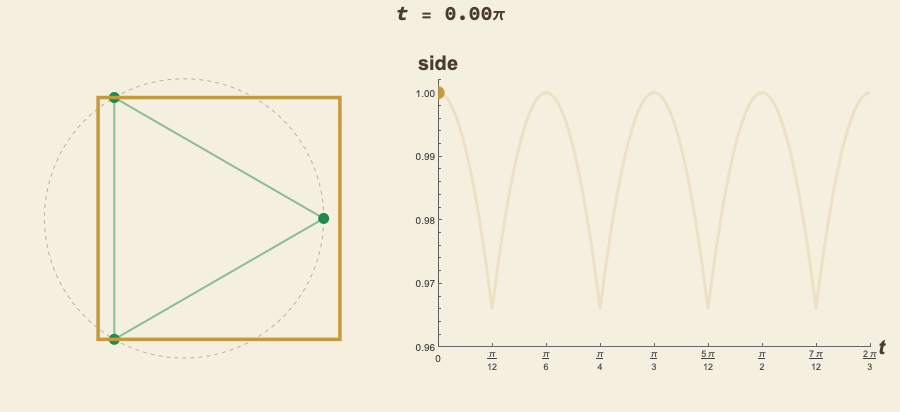


We can see that the _minimum side length is achieved whenever a vertex is in the corner of the square_! This makes sense why there are so many minima in the plot, as the triangle rotates, each vertex of the triangle will be in each corner of the square once which gives 12 minima per full rotation.

---

|